 ## Imports & load data:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load processed data
train_df = pd.read_csv('../data/processed/train.csv')
test_df  = pd.read_csv('../data/processed/test.csv')
df       = pd.concat([train_df, test_df]).reset_index(drop=True)
df['date'] = pd.to_datetime(df['date'])

# ── Load YOUR scalers (matching Phase 3 naming) ──
with open('../models/scaler_X.pkl', 'rb') as f:
    scaler_X = pickle.load(f)
with open('../models/scaler_Y.pkl', 'rb') as f:
    scaler_Y = pickle.load(f)

# ── Rebuild feature_cols the same way as Phase 3 ──
feature_droped = ["Appliances", "date"]
feature_cols = [col for col in df.columns if col not in feature_droped]

X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

print(f"Data loaded successfully!")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Feature cols ({len(feature_cols)}): {feature_cols}")

Data loaded successfully!
Train: (14981, 42) | Test: (3746, 42)
Feature cols (42): ['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'day_of_week', 'month', 'is_weekend', 'day_of_year', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_1', 'lag_6', 'lag_12', 'lag_144', 'lag_1008', 'rolling_mean_6', 'rolling_mean_144', 'rolling_std_6']


## Select clustering features:

In [3]:
from sklearn.preprocessing import StandardScaler
# Use meaningful features for clustering — energy + time patterns
cluster_features = [
        'Appliances', 'hour', 'day_of_week', 'is_weekend',
    'T1', 'RH_1', 'T_out', 'RH_out', 'Windspeed',
    'rolling_mean_6', 'rolling_mean_144'
]
# Make sure all exist in df
cluster_features = [col for col in cluster_features if col in df.columns]
print(f"Clustering features ({len(cluster_features)}): {cluster_features}")

cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(df[cluster_features])

print(f"Clustering data shape: {X_cluster.shape}")

Clustering features (11): ['Appliances', 'hour', 'day_of_week', 'is_weekend', 'T1', 'RH_1', 'T_out', 'RH_out', 'Windspeed', 'rolling_mean_6', 'rolling_mean_144']
Clustering data shape: (18727, 11)


## Elbow method to find optimal K:

K=2, Inertia=168843.39
K=3, Inertia=148487.84
K=4, Inertia=135801.92
K=5, Inertia=126920.86
K=6, Inertia=118343.55
K=7, Inertia=111011.23
K=8, Inertia=104927.52
K=9, Inertia=100908.01
K=10, Inertia=97291.61


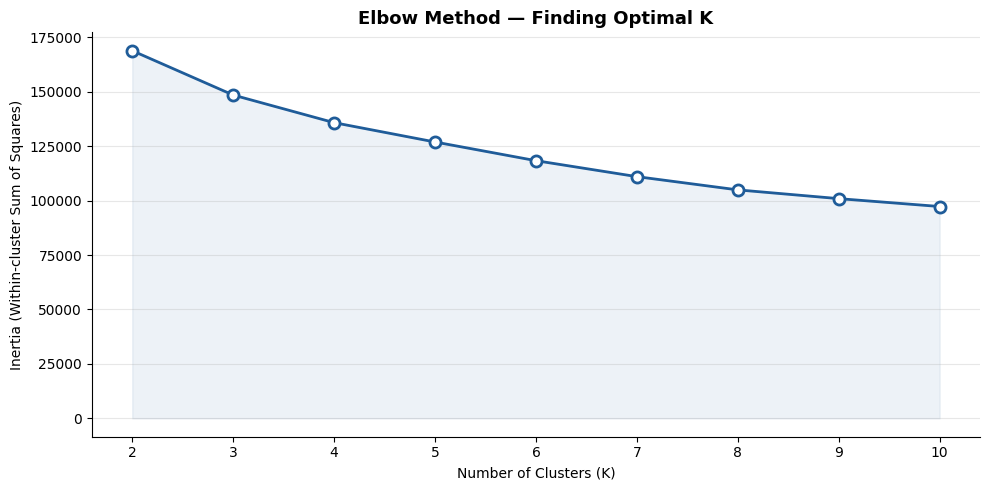

In [6]:

inertia_values=[]

K_range = range(2, 11)

for K in K_range:
    kmeans=KMeans(n_clusters=K, random_state=42,n_init=10)
    kmeans.fit(X_cluster)
    inertia_values.append(kmeans.inertia_)
    print(f"K={K}, Inertia={kmeans.inertia_:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia_values, marker='o', color='#1F5C99',
         linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
plt.fill_between(K_range, inertia_values, alpha=0.08, color='#1F5C99')
plt.title('Elbow Method — Finding Optimal K', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/10_elbow_method.png', bbox_inches='tight')
plt.show()

## Silhouette score for each K:

K=2, Silhouette Score=0.1801
K=3, Silhouette Score=0.1787
K=4, Silhouette Score=0.1801
K=5, Silhouette Score=0.1782
K=6, Silhouette Score=0.1609
K=7, Silhouette Score=0.1687
K=8, Silhouette Score=0.1630
K=9, Silhouette Score=0.1649
K=10, Silhouette Score=0.1652


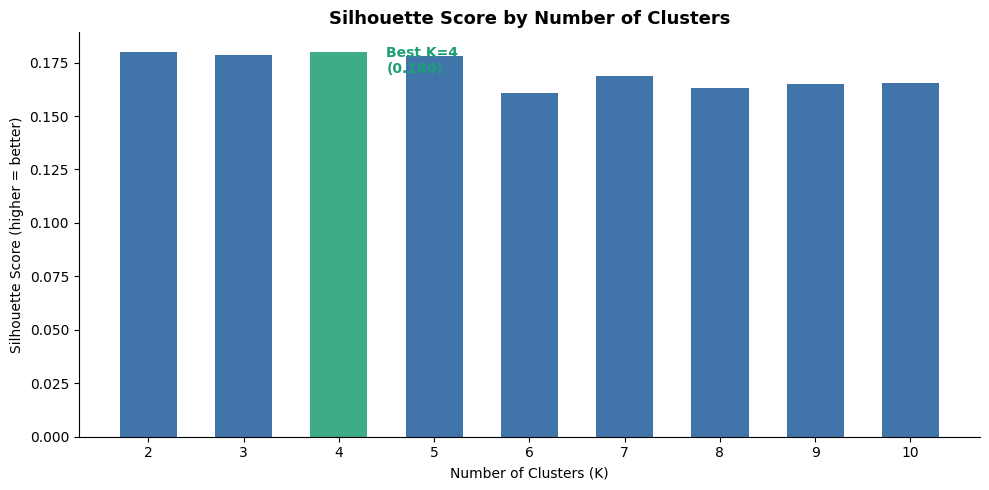


Best K based on Silhouette Score: 4


In [7]:

sil_scores = []
sample_idx = np.random.choice(len(X_cluster), size=3000, replace=False)
X_sample = X_cluster[sample_idx]

for K in K_range:
    km=KMeans(n_clusters=K, random_state=42, n_init=10)
    labels=km.fit_predict(X_sample)
    score=silhouette_score(X_sample, labels)
    sil_scores.append(score)
    print(f"K={K}, Silhouette Score={score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 5))
colors = ['#1D9E75' if s == max(sil_scores) else '#1F5C99' for s in sil_scores]
bars = plt.bar(K_range, sil_scores, color=colors, alpha=0.85, width=0.6)
plt.title('Silhouette Score by Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score (higher = better)')
plt.xticks(K_range)

# Annotate best
best_k = list(K_range)[sil_scores.index(max(sil_scores))]
plt.annotate(f'Best K={best_k}\n({max(sil_scores):.3f})',
             xy=(best_k, max(sil_scores)),
             xytext=(best_k + 0.5, max(sil_scores) - 0.01),
             fontsize=10, color='#1D9E75', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/11_silhouette_scores.png', bbox_inches='tight')
plt.show()

print(f"\nBest K based on Silhouette Score: {best_k}")

## Train final K-Means model:

In [8]:
#Use K=3 (low / medium / high usage) — interpretable and meaningful
Optimal_K = 3
print(f"\nOptimal K for KMeans Clustering: {Optimal_K}")
Kmeans_final = KMeans(n_clusters=Optimal_K, random_state=42, n_init=20,max_iter=500)
df['cluster'] = Kmeans_final.fit_predict(X_cluster)

cluster_means = df.groupby("cluster")["Appliances"].mean().sort_values()

label_map={old:new for new, old in enumerate(cluster_means.index)}
df["cluster"] = df["cluster"].map(label_map)
df["cluster_label"] = df["cluster"].map({0: "Low Usage", 1: "Medium Usage", 2: "High Usage"})

print("\nCluster Summary:")
summary = df.groupby('cluster_label')['Appliances'].agg(['mean','min','max','count'])
summary.columns = ['Mean (Wh)', 'Min (Wh)', 'Max (Wh)', 'Count']
print(summary.round(1))

final_sil = silhouette_score(X_cluster[sample_idx],
                              Kmeans_final.predict(X_cluster[sample_idx]))
print(f"\nFinal Silhouette Score (K={Optimal_K}): {final_sil:.4f}")



Optimal K for KMeans Clustering: 3

Cluster Summary:
               Mean (Wh)  Min (Wh)  Max (Wh)  Count
cluster_label                                      
High Usage         114.9        20       175   5513
Low Usage           56.8        10       175   8549
Medium Usage        76.2        10       175   4665

Final Silhouette Score (K=3): 0.1793


## Visualize clusters on time-series:

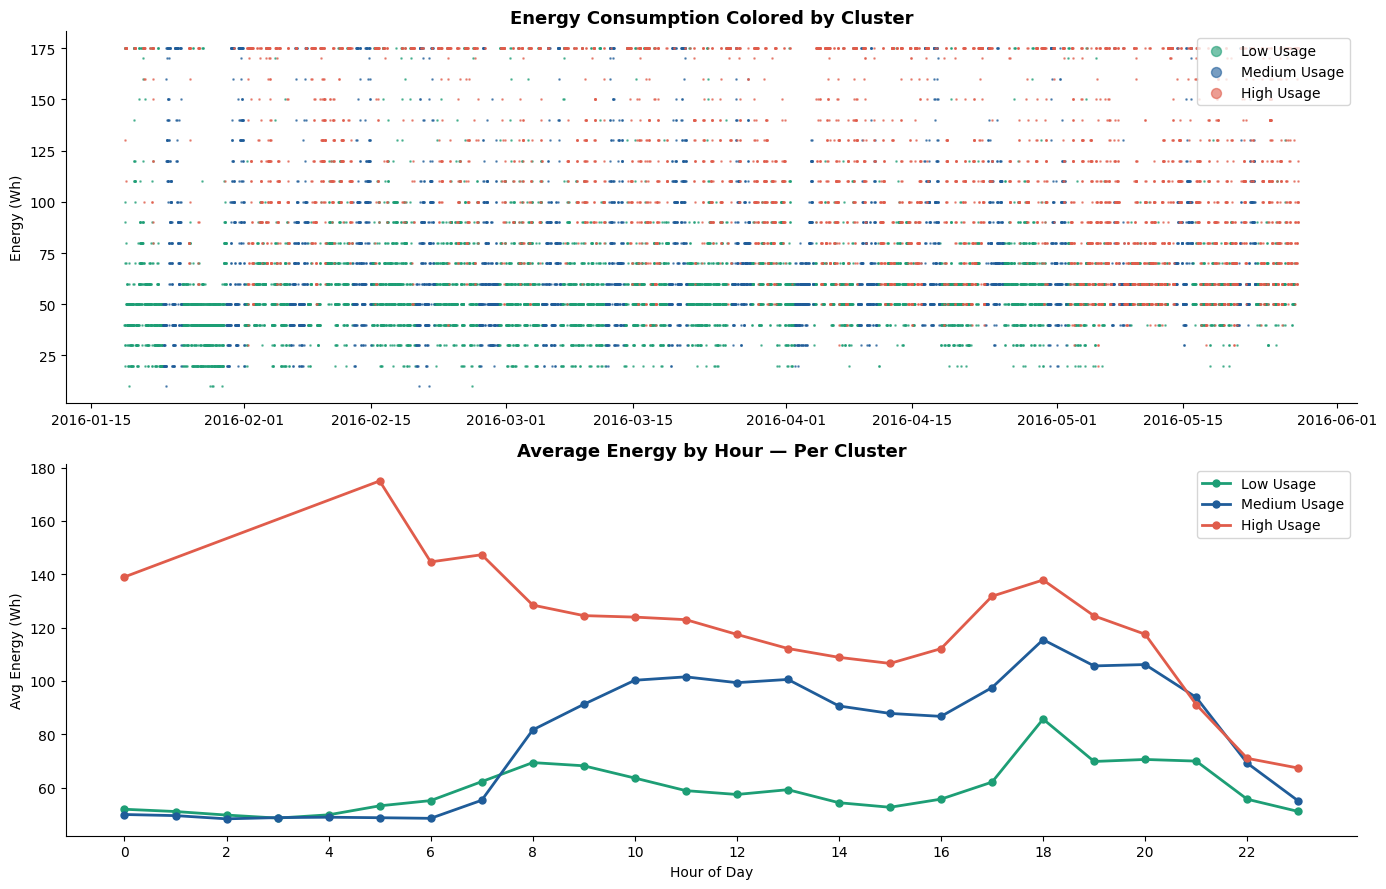

In [9]:
colors_map = {
    'Low Usage':    '#1D9E75',
    'Medium Usage': '#1F5C99',
    'High Usage':   '#E05C4B'
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Full time-series colored by cluster
for label, color in colors_map.items():
    mask = df['cluster_label'] == label
    axes[0].scatter(df.loc[mask, 'date'], df.loc[mask, 'Appliances'],
                    c=color, s=0.8, alpha=0.6, label=label)
axes[0].set_title('Energy Consumption Colored by Cluster', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Energy (Wh)')
axes[0].legend(markerscale=8, loc='upper right')

# Average energy per cluster per hour
pivot = df.groupby(['hour', 'cluster_label'])['Appliances'].mean().reset_index()
for label, color in colors_map.items():
    sub = pivot[pivot['cluster_label'] == label]
    axes[1].plot(sub['hour'], sub['Appliances'], marker='o',
                 label=label, color=color, linewidth=2, markersize=5)
axes[1].set_title('Average Energy by Hour — Per Cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Energy (Wh)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/12_cluster_timeseries.png', bbox_inches='tight')
plt.show()

## PCA visualization of clusters:

Reducing to 2D with PCA for cluster visualization...
Variance explained: PC1=26.3%, PC2=16.4%


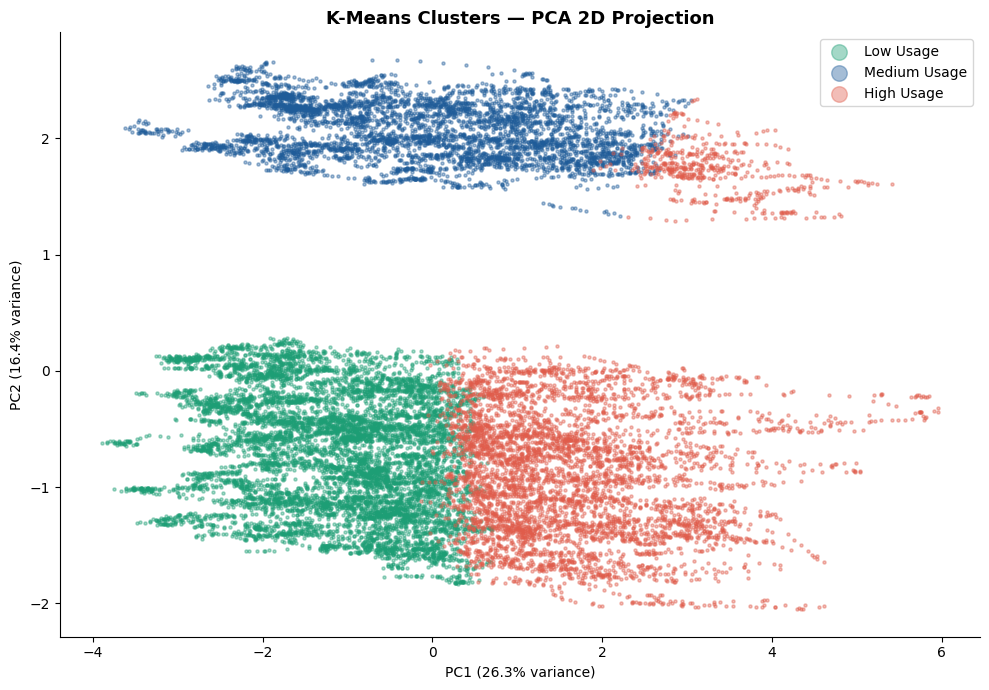

In [10]:
print("Reducing to 2D with PCA for cluster visualization...")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

explained = pca.explained_variance_ratio_ * 100
print(f"Variance explained: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%")

plt.figure(figsize=(10, 7))
for cluster_id, label in enumerate(['Low Usage', 'Medium Usage', 'High Usage']):
    mask = df['cluster_label'] == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=list(colors_map.values())[cluster_id],
                s=5, alpha=0.4, label=label)

plt.title('K-Means Clusters — PCA 2D Projection', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)')
plt.legend(markerscale=5)
plt.tight_layout()
plt.savefig('../outputs/figures/13_cluster_pca.png', bbox_inches='tight')
plt.show()

## Cluster profile analysis:

Cluster Profiles (mean values per cluster):
               Appliances   hour  is_weekend  T_out  RH_out  Windspeed     T1
cluster_label                                                                
High Usage         114.86  16.17        0.09  11.40   68.08       4.33  22.74
Low Usage           56.83   8.76        0.00   5.51   85.33       3.54  21.22
Medium Usage        76.21  11.01        1.00   7.21   81.94       4.41  21.47


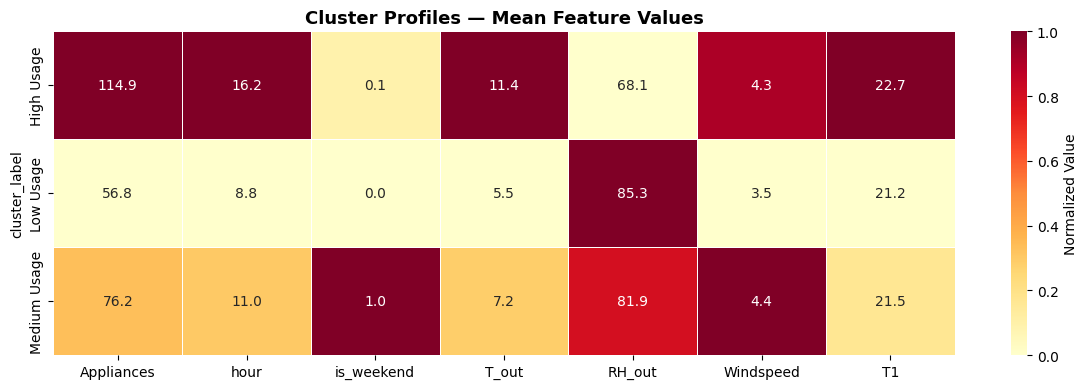

In [11]:
# Deep dive into what makes each cluster unique
profile_features = ['Appliances', 'hour', 'is_weekend', 'T_out', 'RH_out', 'Windspeed', 'T1']
profile_features = [f for f in profile_features if f in df.columns]

profile = df.groupby('cluster_label')[profile_features].mean().round(2)
print("Cluster Profiles (mean values per cluster):")
print(profile.to_string())

# Heatmap of cluster profiles
plt.figure(figsize=(12, 4))
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
sns.heatmap(profile_norm, annot=profile.values, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Normalized Value'})
plt.title('Cluster Profiles — Mean Feature Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/14_cluster_profiles.png', bbox_inches='tight')
plt.show()

## Add cluster feature & save everything:

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# ── Split cluster labels back to train/test ──
train_size = len(train_df)
train_df['cluster'] = df['cluster'].values[:train_size]
test_df['cluster']  = df['cluster'].values[train_size:]

# ── Update processed CSVs with cluster column ──
train_df.to_csv('../data/processed/train.csv', index=False)
test_df.to_csv('../data/processed/test.csv',   index=False)

# ── Rebuild feature_cols with cluster added ──
feature_droped = ["Appliances", "date"]
feature_cols = [col for col in train_df.columns if col not in feature_droped]

print(f"Updated feature list ({len(feature_cols)} features):")
print(feature_cols)

# ── Refit scaler_X with cluster feature included ──
scaler_X_new = MinMaxScaler()
X_train_new  = scaler_X_new.fit_transform(train_df[feature_cols])
X_test_new   = scaler_X_new.transform(test_df[feature_cols])

print(f"\nX_train_new shape: {X_train_new.shape}")
print(f"X_test_new  shape: {X_test_new.shape}")

# ── Save updated numpy arrays ──
np.save('../data/processed/X_train.npy', X_train_new)
np.save('../data/processed/X_test.npy',  X_test_new)

# ── Save scaler_X (updated), scaler_Y stays the same ──
with open('../models/scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X_new, f)

# ── Save feature_cols list ──
with open('../models/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

# ── Save KMeans model and cluster scaler ──
with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(Kmeans_final, f)
with open('../models/cluster_scaler.pkl', 'wb') as f:
    pickle.dump(cluster_scaler, f)

print("\nAll files saved:")
print("  data/processed/train.csv          (with cluster column)")
print("  data/processed/test.csv           (with cluster column)")
print("  data/processed/X_train.npy        (updated with cluster feature)")
print("  data/processed/X_test.npy         (updated with cluster feature)")
print("  models/scaler_X.pkl               (updated with cluster feature)")
print("  models/scaler_Y.pkl               (unchanged)")
print("  models/feature_cols.pkl           (updated list)")
print("  models/kmeans_model.pkl           (K-Means model)")
print("  models/cluster_scaler.pkl         (cluster StandardScaler)")



Updated feature list (43 features):
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'day_of_week', 'month', 'is_weekend', 'day_of_year', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_1', 'lag_6', 'lag_12', 'lag_144', 'lag_1008', 'rolling_mean_6', 'rolling_mean_144', 'rolling_std_6', 'cluster']

X_train_new shape: (14981, 43)
X_test_new  shape: (3746, 43)

All files saved:
  data/processed/train.csv          (with cluster column)
  data/processed/test.csv           (with cluster column)
  data/processed/X_train.npy        (updated with cluster feature)
  data/processed/X_test.npy         (updated with cluster feature)
  models/scaler_X.pkl               (updated with cluster feature)
  models/scaler_Y.pkl               (unchanged)
  models/feature_cols.pkl           (updated list)
  models/kmeans_model.pkl        